# Viscosity Interpolation

This notebook is the copmutation and generation of plots for the REport:

Viscosity Variation with Temperature

Draft in Google Drive here:

https://docs.google.com/document/d/1rMQxd-Eqf6_fCpH0JU7dY3RrDwhEmaOF/edit?usp=sharing&ouid=112738556987743288660&rtpof=true&sd=true

This notebook, when run, should generate the plots for that document, and data for the code in adios_db

## TO BE DONE:

Some more review, and removal of a few outliers -- notably the one in Crude Oil NOS.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot  as plt
import matplotlib
import adios_db.scripting as ads
import adios_db.computation.physical_properties as pp
import csv
import scipy

matplotlib.rcParams['figure.max_open_warning'] = 240

In [2]:
# Set the data dir for your machine
DATA_PATHS = [Path(r"C:\Users\rintaro.moriyasu\Oil Databases\noaa-oil-data\data\oil"),
              Path(r"/Users/chris.barker/Hazmat/GitLab/noaa-oil-data-production/data/oil"),
             ]
# Look for which one is real
for p in DATA_PATHS:
    if p.is_dir():
        DATA_DIR = p
        break
print("Using data in:", DATA_DIR)

Using data in: /Users/chris.barker/Hazmat/GitLab/noaa-oil-data-production/data/oil


In [3]:
# these are orimulsions
no_list = {'AD01706', 'EC00662', 'AD02290', 'AD02599', 'AD00005', 'AD00458', 'AD00459'} 
product_types_to_use = {
"Crude Oil NOS",
"Condensate",
"Bitumen Blend",
"Bitumen",
"Refined Product NOS",
"Distillate Fuel Oil",
"Residual Fuel Oil",
"Refinery Intermediate",
"Solvent",
"Bio-fuel Oil",
"Natural Plant Oil",
"Lube Oil",
"Dielectric Oil",
# # "Other"
}

oil_records = {}

# get all the records, and sort by product type
for oil, filename in ads.get_all_records(DATA_DIR):
    product_type = oil.metadata.product_type
    if oil.oil_id in no_list:
        continue
    if product_type in product_types_to_use:
        oil_records.setdefault(product_type, []).append(oil)


product type in: Condensate
returning Condensate
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in: Crude Oil NOS
returning Crude Oil NOS
product type in:

In [4]:
print("Got data for: ", oil_records.keys())

Got data for:  dict_keys(['Crude Oil NOS', 'Condensate', 'Distillate Fuel Oil', 'Refined Product NOS', 'Residual Fuel Oil', 'Refinery Intermediate', 'Bitumen Blend', 'Dielectric Oil', 'Lube Oil', 'Solvent', 'Natural Plant Oil', 'Bitumen', 'Bio-fuel Oil'])


In [13]:
def compute_regression(density_values, kv2_values):
    """
    compute the regression -- really one call, but this gives us room for corrections, etc.
    """
    res = scipy.stats.linregress(density_values, kv2_values, alternative='two-sided')
    slope = float(res.slope)
    intercept = float(res.intercept)
    rvalue = float(res.rvalue)
    min_kv2 = float(min(kv2_values))
    # sanity check (needed for lube oils)
    if abs(slope) < 10:  # totally arbitrary small value
        slope = 0.0
        intercept = float(np.mean(kv2_values))
        min_kv2 = intercept
    return slope, intercept, rvalue, min_kv2



Crude Oil NOS
Slope: 23.9915
Intercept: -15357.3
Minimum: 148.708

Condensate
Slope: 113.856
Intercept: -80982.8
Minimum: 578.825

Distillate Fuel Oil
Slope: 46.4477
Intercept: -35221.7
Minimum: 19.3642

Refined Product NOS
Slope: 110.659
Intercept: -97137.7
Minimum: 2850.91

Residual Fuel Oil
Slope: 73.4818
Intercept: -59654.2
Minimum: 7963.31

Refinery Intermediate
Slope: 26.0705
Intercept: -18350
Minimum: 239.37

Bitumen Blend
Slope: 57.0098
Intercept: -46883.3
Minimum: 4975.38

Dielectric Oil
Slope: 14.2913
Intercept: -8598.18
Minimum: 3287.23

Lube Oil
Slope: 0
Intercept: 4806.97
Minimum: 4806.97

Solvent
Slope: 0
Intercept: 2389.05
Minimum: 2389.05

Natural Plant Oil
Slope: 80.1166
Intercept: -70176
Minimum: 3787.63

Bio-fuel Oil
Slope: -35.3808
Intercept: 33221.9
Minimum: 1864.63


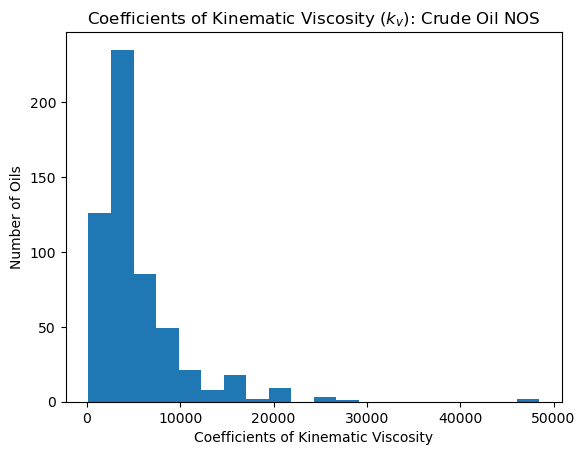

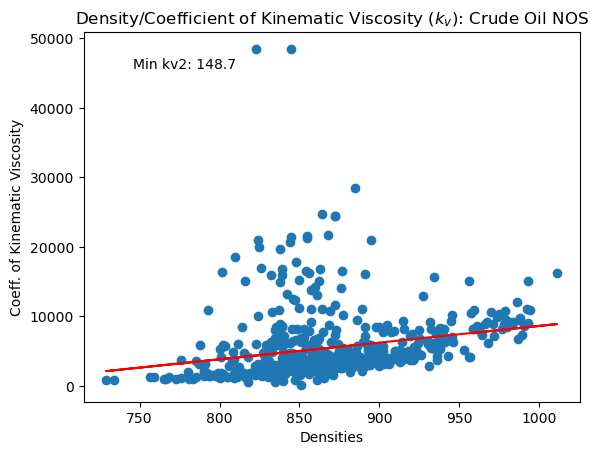

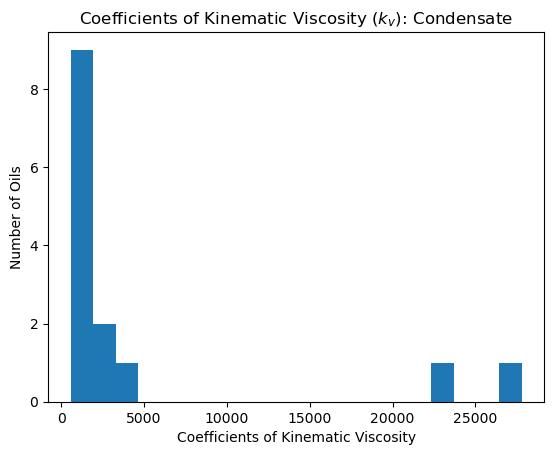

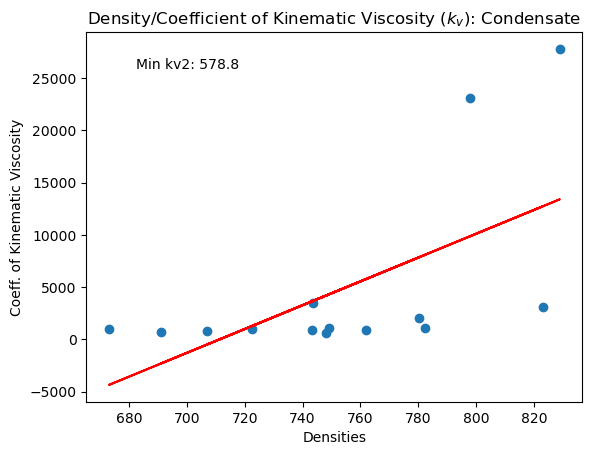

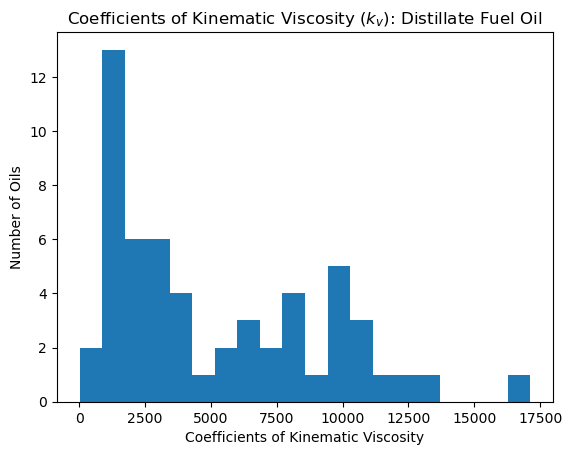

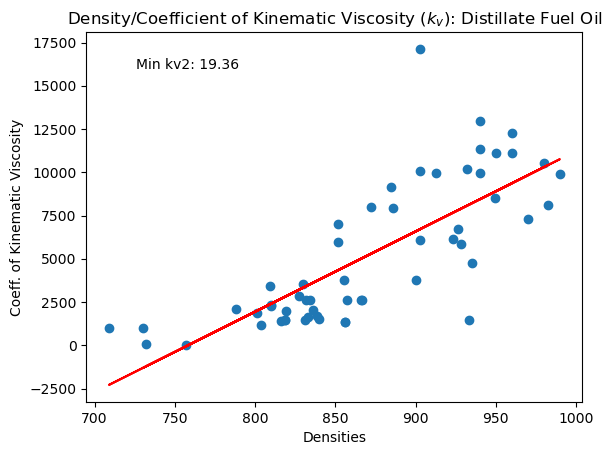

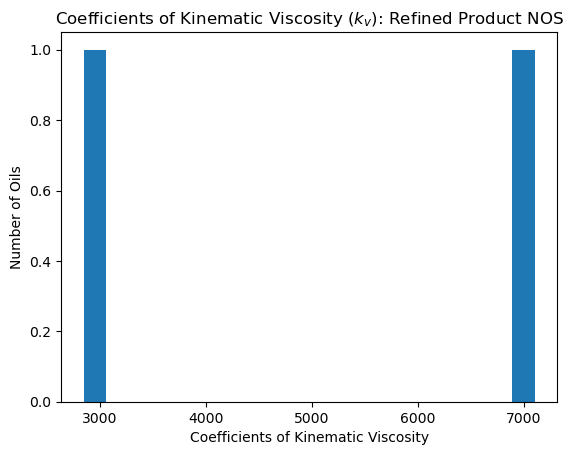

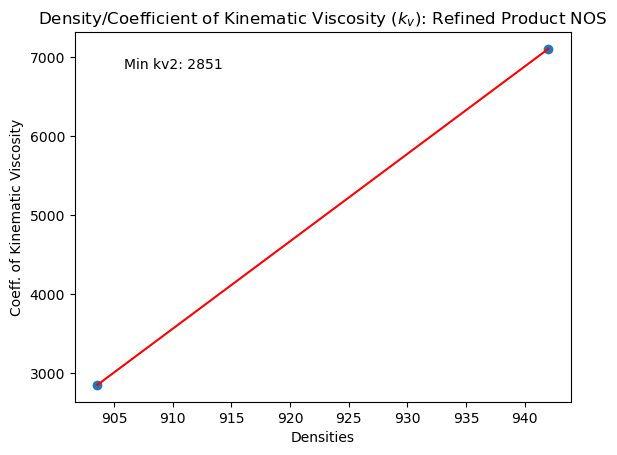

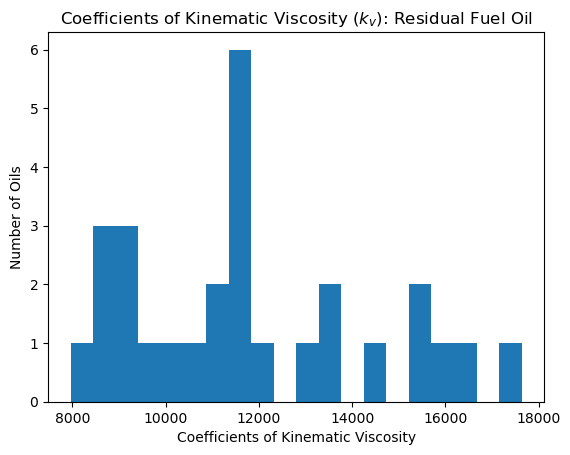

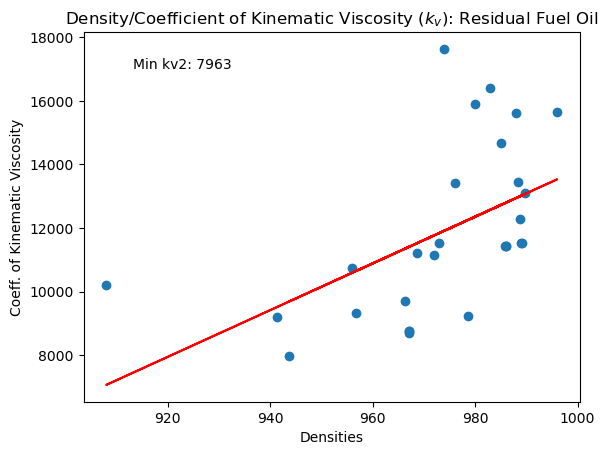

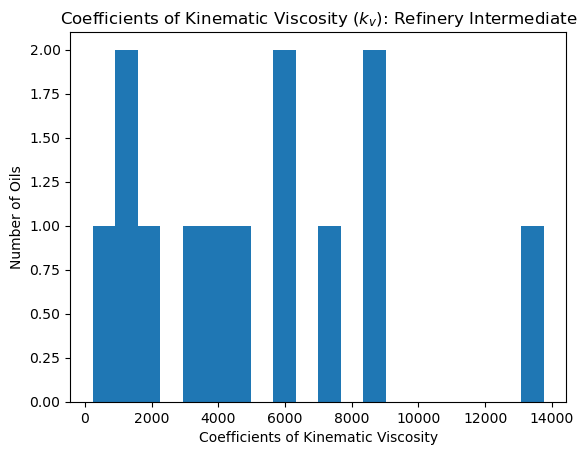

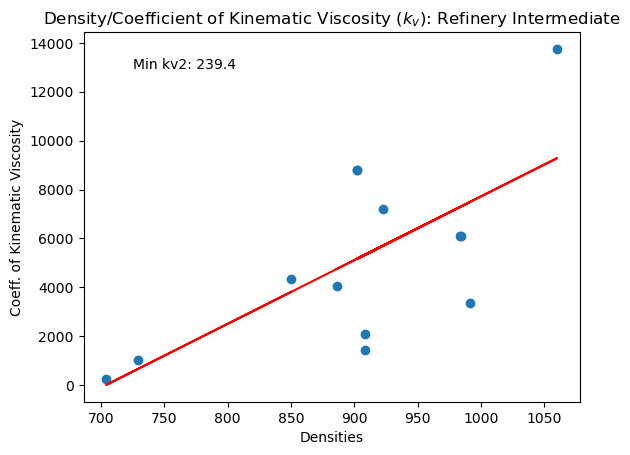

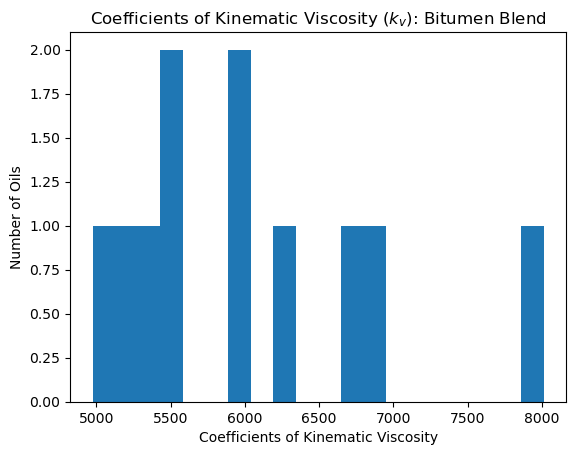

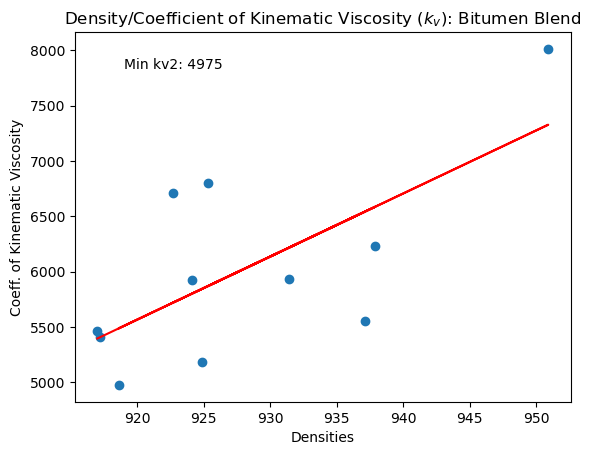

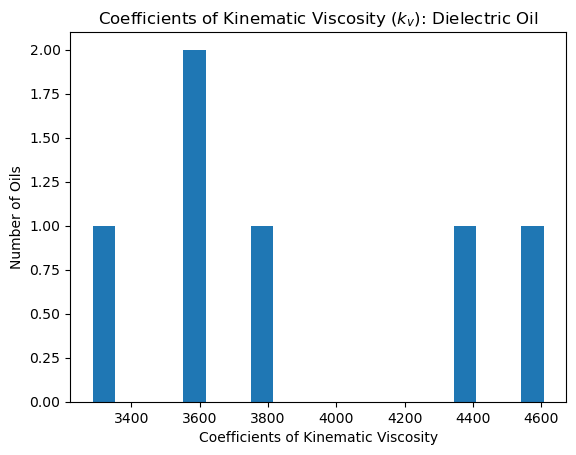

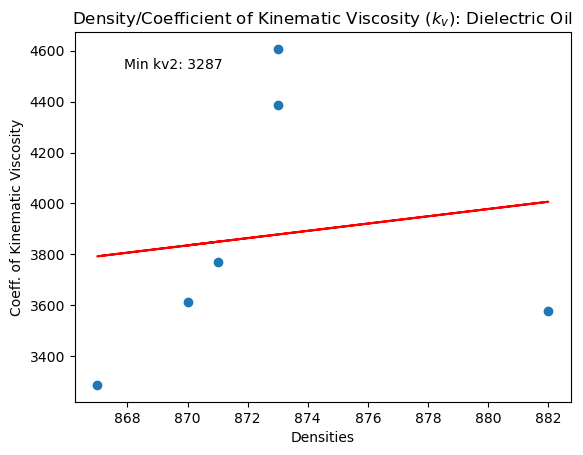

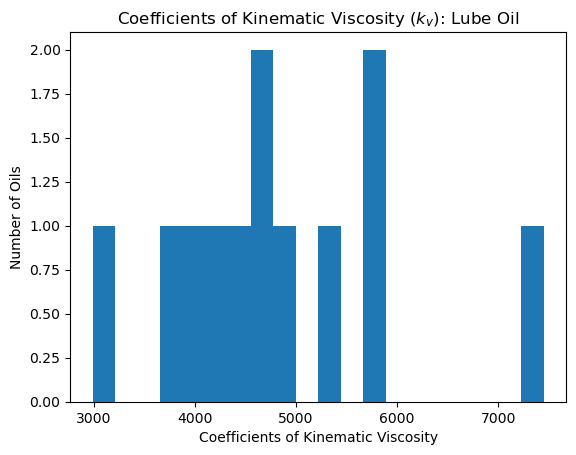

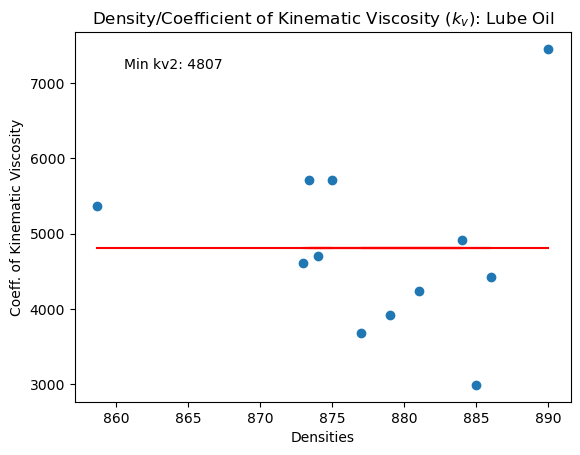

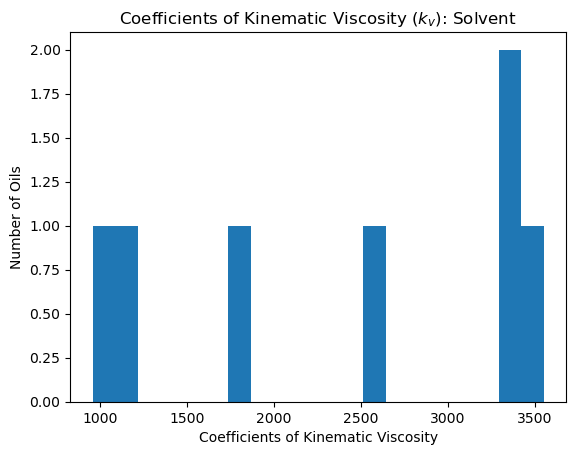

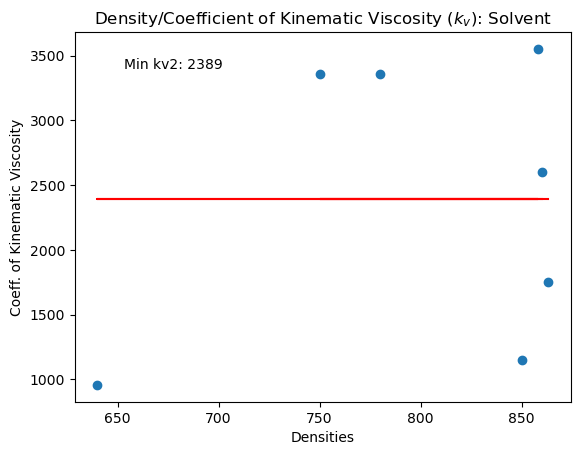

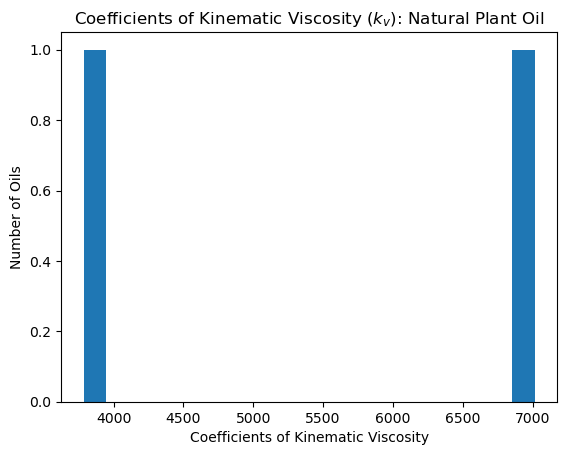

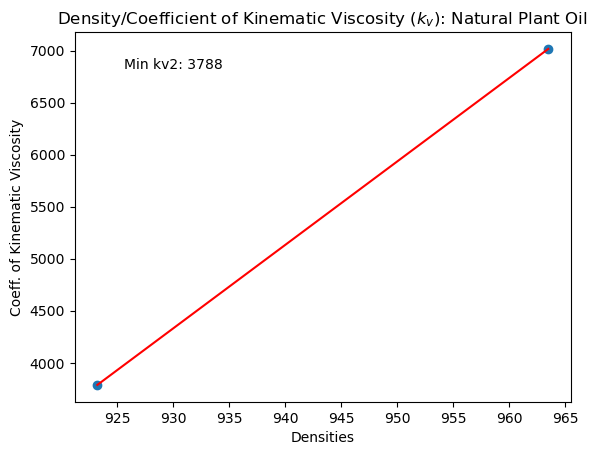

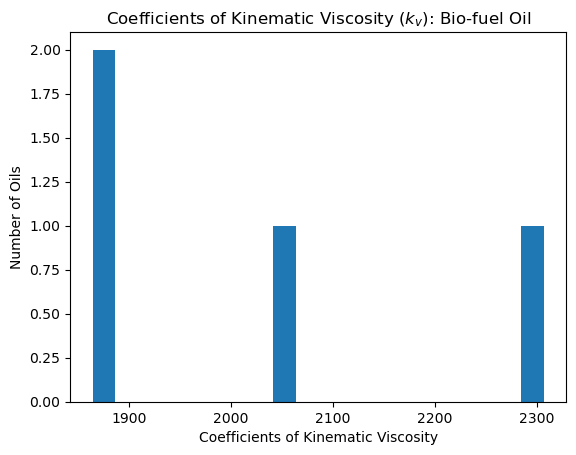

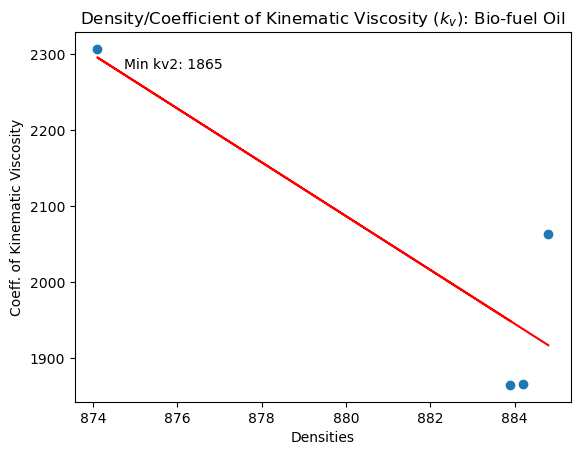

In [14]:
# A dict to store the results (copy and pastable into the adios_db code)
slope_intercept_kv2 = {}

# Do the calculation for each product type:
for pt, oil_recs in oil_records.items():
    # find the records that have more than two Viscosities
    kv2_values = []
    density_values = []
    oil_ids = []
    for oil in oil_recs:
        kv_data = oil.sub_samples[0].physical_properties.kinematic_viscosities
        if not kv_data: # if no kinematic vicosity, use dynamic
            kv_data = oil.sub_samples[0].physical_properties.dynamic_viscosities
            if not kv_data:
                # no dynamic vicosity data either -- skip
                continue
        errors = kv_data.validate()
        if errors: # somethign wrong with the data -- don't use.
            continue
        try:
            KV = pp.KinematicViscosity(oil)
        except ValueError: # couldn't create a KinematicViscosity object -- why not?
             continue
        except:
            # print(oil.oil_id)
            # print(oil.sub_samples[0].physical_properties.kinematic_viscosities)
            # print(oil.sub_samples[0].physical_properties.dynamic_viscosities)
            # print(oil.sub_samples[0].physical_properties.densities)
            continue
        # make sure there is density data, too:
        if len(oil.sub_samples[0].physical_properties.densities) == 0:
            continue          
        if len(KV.kviscs) > 1:
            k_v2 = KV._k_v2
            #if k_v2 < 28000:
            density = pp.Density(oil)
            d = density.at_temp(15, unit = 'C')
            if k_v2 < 0:
                print(f"Wowa! -- {oil.oil_id}, {k_v2}")
                print(oil.validate())
            if True:
                density_values.append(d)
                #print(density_values[-1], oil.oil_id)
                kv2_values.append(k_v2)
                oil_ids.append(oil.oil_id)
    #         else:
    #             print("Removing", oil.oil_id)
    #         if k_v2 > 24000:
    #             print(oil.oil_id)
    if kv2_values:
        fig, ax = plt.subplots()
        ax.hist(kv2_values, bins = 20)
        ax.set_title("Coefficients of Kinematic Viscosity ($k_v$): " + pt)
        plt.xlabel("Coefficients of Kinematic Viscosity")
        plt.ylabel("Number of Oils")
        
        fig.savefig(f"kvisc_plot_{pt}.png", dpi=600)
        fig, ax = plt.subplots()
        ax.scatter(density_values, kv2_values)
        ax.set_title("Density/Coefficient of Kinematic Viscosity ($k_v$): " + pt)
        ax.set_xlabel("Densities")
        ax.set_ylabel("Coeff. of Kinematic Viscosity")
        density_values = np.array(density_values)
        if len(density_values ) > 1: # can't do a regression with one point.
            slope, intercept, rvalue, min_kv2 = compute_regression(density_values, kv2_values)
            # res = scipy.stats.linregress(density_values, kv2_values, alternative='two-sided')
            # ax.plot(density_values, res.intercept + res.slope*density_values, 'r', label='fitted line')
            ax.plot(density_values, intercept + slope*density_values, 'r', label='fitted line')
        ax.text(0.1, 0.9, f"Min kv2: {min_kv2:.4g}", transform=ax.transAxes)
        fig.savefig(f"density_kvis_plot_{pt}.png", dpi=600)
        slope_intercept_kv2[pt] =  (slope, intercept, min_kv2)
        print(f"\n{pt}")
        print(f"Slope: {slope:.6g}")
        print(f"Intercept: {intercept:.6g}")
        print(f"Minimum: {min_kv2:.6g}")

In [15]:
from pprint import pprint
pprint(slope_intercept_kv2)


{'Bio-fuel Oil': (-35.38083731539273, 33221.861943825446, 1864.6319412651287),
 'Bitumen Blend': (57.0098013105482, -46883.25794309046, 4975.3797142363555),
 'Condensate': (113.85627373625817, -80982.84503070948, 578.8245147092716),
 'Crude Oil NOS': (23.991510744131457, -15357.265090333929, 148.70771832267968),
 'Dielectric Oil': (14.291295675366111, -8598.1815248434, 3287.232879657373),
 'Distillate Fuel Oil': (46.447713038535895,
                         -35221.68741027304,
                         19.364150795627832),
 'Lube Oil': (0.0, 4806.966168072863, 4806.966168072863),
 'Natural Plant Oil': (80.11660887308639,
                       -70176.0257133979,
                       3787.6275982354664),
 'Refined Product NOS': (110.6592861637017,
                         -97137.65686690569,
                         2850.912416724771),
 'Refinery Intermediate': (26.07049770263108,
                           -18349.98627361308,
                           239.3701601223172),
 'Residual F